**I.I. Beterov, K.V.Kozenko, P.Xu, I.I. Ryabtsev. This notebook studies single-photon counterdiabatic gate in comparison with Levine-Pichler, time-optimal and amplitude-robust gate protocols. Effect of finite blockade strenght, robustness to variation of Rabi frequency and effect of spontaneous decay are investigated. We use Rydopt 0.2.0 package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

C:\ProgramData\anaconda3\envs\RydOp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Defining analytical shapes for counterdiabatic pulses**

In [2]:
def phase_step(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    phase = ansatz_params[0]
    return phase*jnp.heaviside(t-duration/2,1)

    
def double_sin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    return amplitude1*jnp.sin(2*jnp.pi*(t-t1)/duration)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.sin(2*jnp.pi*(t-t2)/duration)*jnp.heaviside(t-duration/2,1)



def double_exp(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    return amplitude1*jnp.exp(-((t-t1)/wt)**4)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.exp(-((t-t2)/wt)**4)*jnp.heaviside(t-duration/2,1)


def counterdia(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    if len(ansatz_params)>2:
        RabiArray = ansatz_params[0::2]
        Rabi1=RabiArray[0]
        Rabi2=RabiArray[1]
    else: 
        Rabi1=ansatz_params[0]
        Rabi2=Rabi1

    if len(ansatz_params)>3:    
        detuningArray= ansatz_params[1::2]
        detuning1=detuningArray[0]
        detuning2=detuningArray[1]
    else:
        detuning1=ansatz_params[1]
        detuning2=detuning1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    
    
    def Delta(t,t_c=0.0,detuning=detuning1):
        return detuning*(jnp.sin(2*jnp.pi*(t-t_c)/duration))
                         
    def OmegaRe(t,t_c=0.0,Rabi=Rabi1):
        return Rabi*(jnp.exp(-((t-t_c)/wt)**4))
                     
    def Derive(t,t_c=0.0,Rabi=Rabi1,detuning=detuning1):
        return (Delta(t,t_c,detuning)*Rabi*4*((t-t_c)**3)*jnp.exp(-((t-t_c)/wt)**4)/(wt**4)+OmegaRe(t,t_c,Rabi)*detuning*2*jnp.pi*jnp.cos(2*jnp.pi*(t-t_c)/duration)/duration)/(OmegaRe(t,t_c,Rabi1)**2+Delta(t,t_c,detuning1)**2)
                     
           
    return jnp.heaviside(duration/2-t,0)*Derive(t,t1,Rabi1,detuning1)+jnp.heaviside(t-duration/2,1)*Derive(t,t2,Rabi2,detuning2)    

**Defining plot function for counterdiabatic pulses**

In [3]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
import matplotlib.pyplot as plt
def plot_pulse_counter(
    pulse: PulseAnsatz,
    params: PulseParams,
    
    ) -> tuple[plt.Figure, plt.Axes]:
    
    duration = params[0]
    num_points=1024
    times = jnp.linspace(0, duration, num_points)

    # Evaluated pulse
  
    values = np.array(pulse.evaluate_pulse_functions(times, params))


    labels = np.array(
        [
            r"$\Delta(t)$",
            r"$\Omega_{CD}(t)$",
            r"$\Omega_{0}(t)$",
        ]
    ) 

    ylabel = ", ".join(
        np.array(
            [
                r"$T\Delta(t)$",
                r"$T\Omega_{CD}(t)$",
                r"$T\Omega_{0}(t)$",
            ]
        ) 
    )

  
    fig, ax = plt.subplots(figsize=(4, 3))
    for v, label in zip(values, labels):
        ax.plot(times, v, label=label)
    ax.set_xmargin(0)
    ax.set_xlabel(r"$t /T$")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.savefig('pulse_plot.svg', format='svg')
    return fig, ax

**Here we design the initial pulse shape**

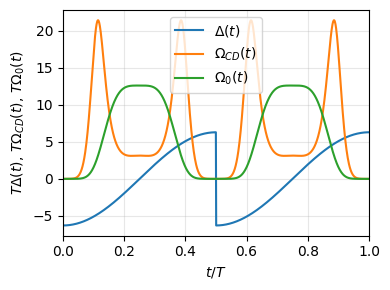

In [4]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])
fixed_initial_params = (True, [False], [False], [False])
plot_pulse_counter(pulse_ansatz, initial_params);

**For counterdibatic gate with infinite blockade strength we write the Hamiltonian which includes real and complex part of Rabi frequency instead of amplitude and phase**

In [5]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateCounter:
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex), jnp.array([1,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
           
            return jnp.array(
                [
                   [0,(Omega-1j*Xi)*0.5],
                   [(Omega+1j*Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
           
            return jnp.array(
                 [
                   [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2)],
                   [(Omega+1j*Xi)*0.5*jnp.sqrt(2),Delta]
                                                        
                ]
            )
        return hamiltonian1, hamiltonian2

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Checking raw fidelity without optimization**

In [6]:
gate = CZGateCounter()
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99999992, dtype=float64)

**Testing numeric optimization of the gate performance. Here we fix duration time**

In [7]:
gate = CZGateCounter()
fixed_initial_params = (True, [False], [False, False], [False])
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params, tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:20<00:00, 47.99it/s, infidelity=9.28e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 33.653 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (1.0, [6.28312236], [12.59097392  6.28433637], [12.58874766])
> duration = 1.0


**Now we define the gate with finite blockade strength**

In [8]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateCounterV:

    def __init__(self, Vnn: float):
        self._Vnn = Vnn
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex), jnp.array([1,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
           
            return jnp.array(
                [
                   [0,(Omega-1j*Xi)*0.5],
                   [(Omega+1j*Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            
            return jnp.array(
                 [
                   [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2),0],
                   [(Omega+1j*Xi)*0.5*jnp.sqrt(2),Delta,(Omega+1j*Xi)*0.5*jnp.sqrt(2)],
                    [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2),2*Delta+self._Vnn]                                    
                ]



                
            )
        return hamiltonian1, hamiltonian2

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Testing the fidelity for low blockade strength**

In [9]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*2*jnp.pi ], [2.003*2*jnp.pi ,1.0*2*jnp.pi ], [2.003*2*jnp.pi ])
gate = CZGateCounterV(Vnn=100)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states)

Array(0.02706949, dtype=float64)

**Here we study the dependence of fidelity on blockade strenght for unoptimized gate**

In [10]:
Vnnlist=[100,500,1000,2000,4000]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])
Fun=[]
for i in range(5):
    gate = CZGateCounterV(Vnn=Vnnlist[i])
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Fun.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Fun

[0.027069490006719765,
 0.0009423383911507655,
 0.00023502723498680655,
 5.8760686131087425e-05,
 1.4747658800939867e-05]

**Optimizing for finite blockade strength. Here we vary the amplitude of each pulse independently**

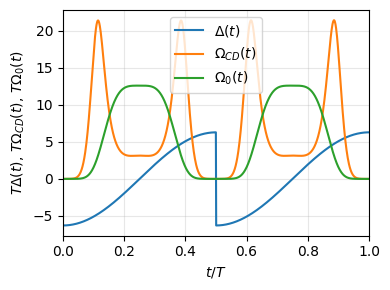

In [11]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
gate = CZGateCounterV(Vnn=100)
initial_params=(1,[2.0*jnp.pi,2.0*np.pi], [2.0*2.0003*jnp.pi,2.0*jnp.pi,2*2.003*jnp.pi,2.0*jnp.pi], [2*2.003*jnp.pi, 2*2.003*jnp.pi])
plot_pulse_counter(pulse_ansatz, initial_params);
fixed_initial_params = (True, [False, False], [False, False,False, False], [False, False])

In [12]:
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params,  tol=1e-6,num_steps=2000)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [02:41<00:00, 12.38it/s, infidelity=4.25e-05, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 184.912 seconds
Gates with infidelity below tol=1.0e-06: 0

Optimized gate:
> infidelity = 4.249525e-05
> parameters = (1.0, [10.86114266 12.60796536], [10.60346554  8.03096377 12.4074725   6.12008796], [14.42220038 16.38300249])
> duration = 1.0


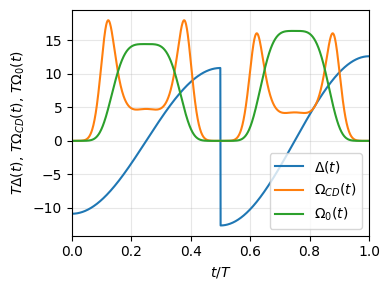

In [20]:
plot_pulse_counter(pulse_ansatz, optimized_params);

**calculating gate phase shift**

In [21]:
print("phase shift:", 2*jnp.angle(time_evolved_basis_states[0][0].item())-jnp.angle(time_evolved_basis_states[1][0].item()))

phase shift: -3.51544755538364


**Here we optimize the gate for finite blockade strength**

In [25]:
Vnnlist=[100,500,1000,2000,4000]
Funopt=[]
for i in range(5):
    gate = CZGateCounterV(Vnn=Vnnlist[i])
    opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params, tol=1e-9,num_steps=2000)
    Funopt.append(opt_result.infidelity)
Funopt

Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [04:20<00:00,  7.67it/s, infidelity=4.26e-05, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 268.161 seconds
Gates with infidelity below tol=1.0e-09: 0

Optimized gate:
> infidelity = 4.258538e-05
> parameters = (1.0, [10.86138133 12.60817234], [10.60322935  8.03104308 12.4075269   6.12014168], [14.42238714 16.38309728])
> duration = 1.0
Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [04:27<00:00,  7.47it/s, infidelity=4.80e-09, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 275.192 seconds
Gates with infidelity below tol=1.0e-09: 0

Optimized gate:
> infidelity = 4.795361e-09
> parameters = (1.0, [6.19725784 6.27892467], [12.74586688  6.30317511 12.45063137  6.15435444], [12.55415621 13.32127822])
> duration = 1.0
Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [05:34<00:00,  5.98it/s, infidelity=1.48e-08, converged=0/1]

=

[4.258538306600723e-05,
 4.795361441267687e-09,
 1.4828255734400386e-08,
 1.0752596590890562e-09,
 7.078415631411872e-10]

In [6]:
Funopt=[4.258538306600723e-05,
 4.795361441267687e-09,
 1.4828255734400386e-08,
 1.0752596590890562e-09,
 7.078415631411872e-10]

**Comparing with other gate schemes. First, we plot the phase profile for Levine-Pichler and time-optimal gates**

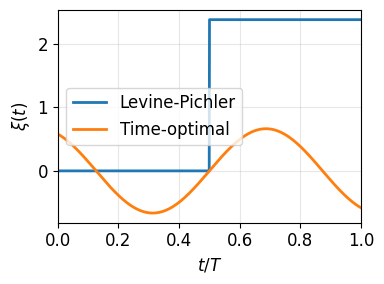

In [62]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
pulse_ansatz_1 = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const
)
initial_params1=(1,[-0.37736613*8.585308327286219],[2.38073847],[8.585308327286219])
pulse_ansatz_2 = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params2=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])
duration = 1
num_points=1024
times = jnp.linspace(0, duration, num_points)
values1 = np.array(pulse_ansatz_1.evaluate_pulse_functions(times, initial_params1))
values2 = np.array(pulse_ansatz_2.evaluate_pulse_functions(times, initial_params2))
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(times, values1[1], label= 'Levine-Pichler')
ax.plot(times, values2[1], label= 'Time-optimal')
ax.set_xmargin(0)
ax.set_xlabel(r"$t /T$")
ylabel = r"$\xi(t)$"
ax.set_ylabel(ylabel)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig('Gate_phase_profiles.svg', format='svg')
plt.show()

**Here we calculate the dependence of fidelity of Levine-Pichler gate on blockade strength**

In [63]:
Vnnlist=[100,500,1000,2000,4000]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const
)
initial_params=(1,[-0.37736613*8.585308327286219],[2.38073847],[8.585308327286219])
FLevine=[]
for i in range(5):
    gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=Vnnlist[i], decay=0.0)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-  gate.process_fidelity(time_evolved_basis_states).item())
FLevine

[0.0060634541931344765,
 0.00022819957630026977,
 5.662331436684376e-05,
 1.4105048538715081e-05,
 3.522443032921707e-06]

**Now we optimize Levine-Pichler gate for each value of blockade strenth**

In [29]:
Vnnlist=[100,500,1000,2000,4000]
fixed_initial_params = (True, [False], [False ], [False])
FLevineOpt=[]
for i in range(5):
    gate =  ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=Vnnlist[i], decay=0.0)
    opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params, tol=1e-9,num_steps=2000)
    FLevineOpt.append(opt_result.infidelity)
FLevineOpt

Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [01:15<00:00, 26.45it/s, infidelity=4.03e-06, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 80.259 seconds
Gates with infidelity below tol=1.0e-09: 0

Optimized gate:
> infidelity = 4.030970e-06
> parameters = (1.0, [-3.41941452], [2.33254244], [8.49019246])
> duration = 1.0
Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [02:44<00:00, 12.13it/s, infidelity=1.82e-09, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 168.666 seconds
Gates with infidelity below tol=1.0e-09: 0

Optimized gate:
> infidelity = 1.822162e-09
> parameters = (1.0, [-3.27356188], [2.37072279], [8.56534699])
> duration = 1.0
Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [00:14<00:00, 140.73it/s, infidelity=5.12e-10, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 18.354 seconds
Gates with infidelity below tol=1.0e-09: 1

Optimized gat

[4.030969686152908e-06,
 1.8221624209502352e-09,
 5.122127166856671e-10,
 4.946645315584419e-10,
 5.959783777598204e-10]

**Here we calculate the dependence of time-optimal gate fidelity on blockade strength**

In [30]:
Vnnlist=[100,500,1000,2000,4000]
pulse_ansatz=ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])
FTO=[]
for i in range(5):
    gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=Vnnlist[i], decay=0.0)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTO.append(1-  gate.process_fidelity(time_evolved_basis_states).item())
FTO

[0.004667867656325542,
 0.00017949689240748246,
 4.463281572730793e-05,
 1.1121762964472204e-05,
 2.7720435752387473e-06]

**Now we optimize time-optimal gate for blockade strength**

In [31]:
Vnnlist=[100,500,1000,2000,4000]
pulse_ansatz=ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])
fixed_initial_params = (True, [False], [False, False], [False])
FTOOpt=[]
for i in range(5):
    gate =  ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=Vnnlist[i], decay=0.0)
    opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params, tol=1e-9,num_steps=2000)
    FTOOpt.append(opt_result.infidelity)
FTOOpt

Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [01:17<00:00, 25.81it/s, infidelity=1.13e-06, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 82.542 seconds
Gates with infidelity below tol=1.0e-09: 0

Optimized gate:
> infidelity = 1.133390e-06
> parameters = (1.0, [0.25304031], [1.22702433 0.61190516], [7.5863149])
> duration = 1.0
Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [03:20<00:00, 10.00it/s, infidelity=1.37e-08, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 204.023 seconds
Gates with infidelity below tol=1.0e-09: 0

Optimized gate:
> infidelity = 1.374743e-08
> parameters = (1.0, [0.28400132], [0.93583011 0.64642227], [7.61621746])
> duration = 1.0
Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [00:17<00:00, 111.21it/s, infidelity=9.61e-10, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 23.411 seconds
Gates with infidelity below tol=1.0e-0

[1.1333899129217784e-06,
 1.3747426530485995e-08,
 9.608782658432347e-10,
 6.472868907536622e-10,
 7.921752143147387e-10]

**This plot compares dependence of fidelity on blockade strength for unoptimized gates**

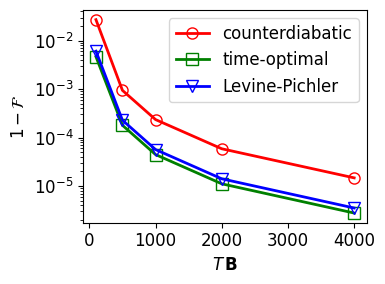

In [64]:
fig, ax = plt.subplots(figsize=(4, 3))

# Plot the first series
ax.plot(Vnnlist, Fun, label='counterdiabatic', color='red', marker='o',mfc='none', markersize=8)

# Plot the second series
ax.plot(Vnnlist, FTO, label='time-optimal', color='green', marker='s', mfc='none', markersize=8)

ax.plot(Vnnlist, FLevine, label='Levine-Pichler', color='blue', marker='v', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$T \,\mathbf{B}$")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Blockade_strength_plot.svg', format='svg')
# Display the plot

**This plot compares dependence of fidelity on blockade strenght for optimized gates**

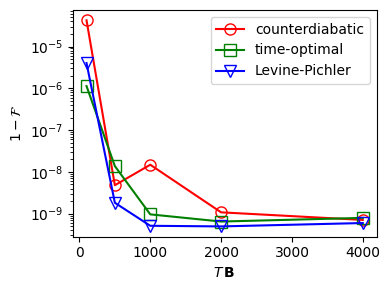

In [33]:
fig, ax = plt.subplots(figsize=(4, 3))

# Plot the first series
ax.plot(Vnnlist, Funopt, label='counterdiabatic', color='red', marker='o',mfc='none', markersize=8)

# Plot the second series
ax.plot(Vnnlist, FTOOpt, label='time-optimal', color='green', marker='s', mfc='none', markersize=8)

ax.plot(Vnnlist, FLevineOpt, label='Levine-Pichler', color='blue', marker='v', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$T \,\mathbf{B}$")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Blockade_strength_plot_Opt.svg', format='svg')
# Display the plot
plt.show()

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

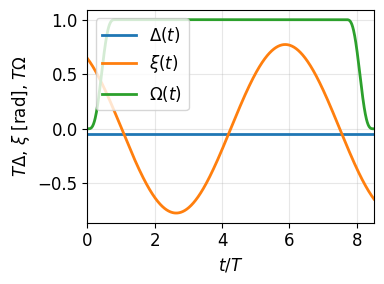

In [97]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
initial_params=(2.09722135*4.058348807763706, [-0.09393892/2.09722135 ], [0.73884332, 0.77225565], [1, 0.19713572])
plot_pulse(pulse_ansatz,initial_params)

In [98]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states).item()

1.0000000018113213

**Here we investigate robustness of different gate schemes to variation of Rabi frequencies**

**Calculating robustness to variation of Rabi frequency for Levine-Pichler gate**

In [65]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevine=[]
optimized_params=(8.585308327286219, [-0.37736613], [2.38073847], [1.])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[1+Eps[i]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevine

[0.00739194899981932,
 0.004816027956094371,
 0.0027597257540947773,
 0.0012502447281491635,
 0.0003187791435186327,
 7.90281573515017e-09,
 0.0003314782913045322,
 0.0013528884228318772,
 0.003105272017038141,
 0.005630095848225269,
 0.008968284095753676]

**Calculating robustness to variation of Rabi frequency for counterdiabatic gate**

In [66]:
gate = CZGateCounter()
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
FCounter=[]

for i in range(len(Eps)):
    initial_params=initial_params[0],initial_params[1],initial_params[2],[(1+Eps[i])*2.003*2*jnp.pi]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FCounter.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FCounter

[0.001087648629232607,
 0.0006998464993499542,
 0.00039665698296798,
 0.00017863597708012158,
 4.6290265686921295e-05,
 7.550189284888376e-08,
 4.039487898332972e-05,
 0.0001675964796730156,
 0.00038197226140856966,
 0.0006837563212298559,
 0.0010731234195280326]

**Defining the amplitude-robust gate rescaled to duration T=1**

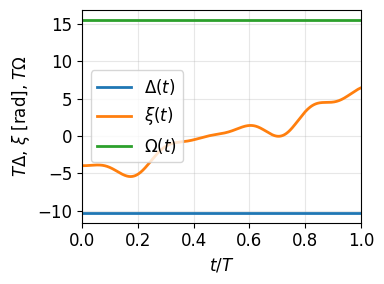

In [67]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const
)
d=15.560089695727132
initial_params=(1,[-0.66202403*d],[0.51990003*d, -0.2527502 ,  0.8859972 , -1.17347235, -0.08802893,
        -0.327713  , -1.00445164,  0.10583959,  1.20175343,  0.62878523,
         0.65908966, -0.25679209, -0.56651597,  1.10736928, -0.32141791,
         0.14352779, -0.2186016 ],[d])
plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

**Calculating robustness for amplitude-robust gate**

In [69]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
FRobust=[]
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
for i in range(len(Eps)):
    initial_params=initial_params[0],initial_params[1],initial_params[2],[d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FRobust.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobust

[0.0005866470795780065,
 0.0003842906218456399,
 0.00023258668018588669,
 0.0001252716582269553,
 5.7798682257304e-05,
 2.7268297698390676e-05,
 3.233066878371993e-05,
 7.306092302106215e-05,
 0.00015081204164202333,
 0.00026804983164807616,
 0.00042817593859556524]

**This plot shows comparison of robustness to variation of Rabi frequency for three gate protocols**

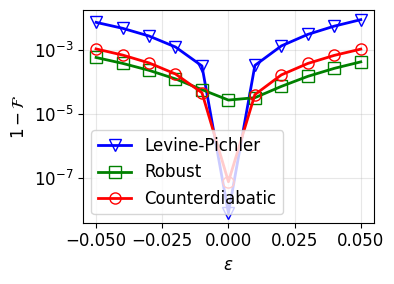

In [72]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Eps, FLevine, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)

# Plot the second series
ax.plot(Eps, FRobust, label='Robust', color='green', marker='s', mfc='none', markersize=8)

# Plot the second series
ax.plot(Eps, FCounter, label='Counterdiabatic', color='red', marker='o', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Robustness_plot.svg', format='svg')
ax.grid(alpha=0.3)
plt.savefig('Robustness.svg', format='svg')
# Display the plot
plt.show()

**Plot pulse function modified to save plot to file**

In [39]:
from typing import cast
def plot_pulse(
    pulse: PulseAnsatz,
    params: PulseParams,
    *,
    plot_detuning: bool = True,
    plot_phase: bool = True,
    plot_rabi: bool = True,
    subtract_phase_offset: bool = False,
    num_points: int = 1024,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    
    duration = params[0]

    times = jnp.linspace(0, duration, num_points)

    # Evaluated pulse
    selector = [plot_detuning, plot_phase, plot_rabi]

    values = np.array(pulse.evaluate_pulse_functions(times, params))
    if subtract_phase_offset:
        values[1] -= values[1][0]
    values = values[selector]

    labels = np.array(
        [
            r"$\Delta(t)$",
            r"$\xi(t)$",
            r"$\Omega(t)$",
        ]
    )[selector]

    ylabel = ", ".join(
        np.array(
            [
                r"$T\Delta $",
                r"$\xi$ [rad]",
                r"$T\Omega $",
            ]
        )[selector]
    )

    # Plot pulse
    owns_ax = ax is None

    if owns_ax:
        fig, ax = plt.subplots(figsize=(4, 3))
    else:
        assert ax is not None
        fig = cast(plt.Figure, ax.figure)

    for v, label in zip(values, labels):
        ax.plot(times, v, label=label)

    if owns_ax:
        ax.set_xmargin(0)
        ax.set_xlabel(r"$t/ T$")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
    plt.savefig('Pulse_plot.svg', format='svg')
    return fig, ax

**Plot of original amplitude-robust gate**

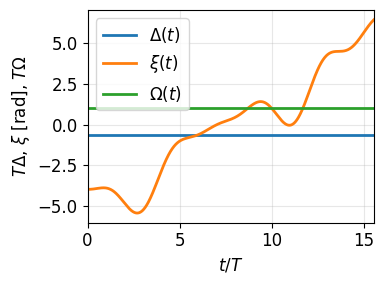

In [40]:
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const
)
initial_params=(15.560089695727132,[-0.66202403],[0.51990003, -0.2527502 ,  0.8859972 , -1.17347235, -0.08802893,
        -0.327713  , -1.00445164,  0.10583959,  1.20175343,  0.62878523,
         0.65908966, -0.25679209, -0.56651597,  1.10736928, -0.32141791,
         0.14352779, -0.2186016 ],[1])
plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

In [41]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states).item()

0.9999727318608003

**Defining pulse profiles with gradient of Rabi frequency**

In [42]:
def double_exp_lin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    lin=ansatz_params[0]
    amplitude1 = ansatz_params[1]
    if len(ansatz_params)>2:
        amplitude2=ansatz_params[2]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    return (amplitude1*(1+lin*(t-0.5*duration)/duration)*jnp.exp(-((t-t1)/wt)**4)*jnp.heaviside(duration/2-t,0)+
            amplitude2*(1+lin*(t-0.5*duration)/duration)*jnp.exp(-((t-t2)/wt)**4)*jnp.heaviside(t-duration/2,1))


def counterdia_lin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    lin=ansatz_params[0]
    if len(ansatz_params)>3:
        RabiArray = ansatz_params[1::2]
        Rabi1=RabiArray[0]
        Rabi2=RabiArray[1]
    else: 
        Rabi1=ansatz_params[1]
        Rabi2=Rabi1

    if len(ansatz_params)>4:    
        detuningArray= ansatz_params[2::2]
        detuning1=detuningArray[0]
        detuning2=detuningArray[1]
    else:
        detuning1=ansatz_params[2]
        detuning2=detuning1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    
    
    def Delta(t,t_c=0.0,detuning=detuning1):
        return detuning*(jnp.sin(2*jnp.pi*(t-t_c)/duration))
                         
    def OmegaRe(t,t_c=0.0,Rabi=Rabi1):
        return Rabi*(jnp.exp(-((t-t_c)/wt)**4))
                     
    def Derive(t,t_c=0.0,Rabi=Rabi1,detuning=detuning1,lin=lin):
        return ((Delta(t,t_c,detuning)*(1+lin*(t-0.5*duration)/duration)*Rabi*4*((t-t_c)**3)*jnp.exp(-((t-t_c)/wt)**4)/(wt**4)+
                 OmegaRe(t,t_c,Rabi)*(1+lin*(t-0.5*duration)/duration)*detuning*2*jnp.pi*jnp.cos(2*jnp.pi*(t-t_c)/duration)/duration)/(OmegaRe(t,t_c,Rabi1)**2+Delta(t,t_c,detuning1)**2))
                     
           
    return jnp.heaviside(duration/2-t,0)*Derive(t,t1,Rabi1,detuning1,lin)+jnp.heaviside(t-duration/2,1)*Derive(t,t2,Rabi2,detuning2,lin)
  

**Plot of counterdiabatic pulse with gradient of Rabi frequency**

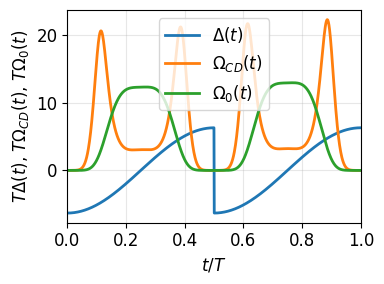

In [73]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia_lin, rabi_ansatz=double_exp_lin
)
initial_params=(1,[1.0*2*jnp.pi], [0.1, 2.003*2*jnp.pi,1.0*2*jnp.pi], [0.1, 2.003*2*jnp.pi])
plot_pulse_counter(pulse_ansatz, initial_params);

**checking fidelity of counterdiabatic gate with gradient**

In [44]:
gate = CZGateCounter()
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99978091, dtype=float64)

**Calculating robustness of counterdiabatic gate on gradient of Rabi frequency**

In [74]:
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
FCounterLin=[]
gate = CZGateCounter()
for i in range(len(Linlist)):
    initial_params=(1,[1.0*2*jnp.pi], [Linlist[i], 2.003*2*jnp.pi,1.0*2*jnp.pi], [Linlist[i], 2.003*2*jnp.pi])
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FCounterLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FCounterLin

[0.00021901449486294577,
 5.1298131440336014e-05,
 7.550190417315861e-08,
 5.128306117940795e-05,
 0.0002190908356289878]

**Defining linear profile of Rabi frequency**

In [46]:
def lin_profile(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    Rabi0 = ansatz_params[0]
    Rabi1 = ansatz_params[1]
    return Rabi0+(Rabi1-Rabi0)*t/duration

**Re-defining amplitude-robust gate with gradient of Rabi frequency**

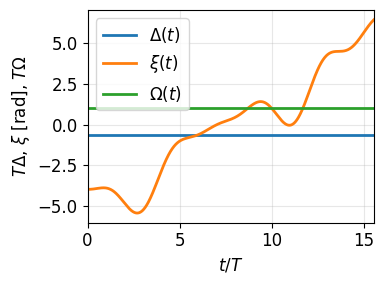

In [78]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
initial_params=(15.560089695727132,[-0.66202403],[0.51990003, -0.2527502 ,  0.8859972 , -1.17347235, -0.08802893,
        -0.327713  , -1.00445164,  0.10583959,  1.20175343,  0.62878523,
         0.65908966, -0.25679209, -0.56651597,  1.10736928, -0.32141791,
         0.14352779, -0.2186016 ],[1,1])
plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

**checking fidelity of amplitude-robust gate**

In [79]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99997273, dtype=float64)

**Calculating robustness of amplitude-robust gate with gradient of Rabi frequency**

In [80]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
initial_params=(15.560089695727132,[-0.66202403],[0.51990003, -0.2527502 ,  0.8859972 , -1.17347235, -0.08802893,
        -0.327713  , -1.00445164,  0.10583959,  1.20175343,  0.62878523,
         0.65908966, -0.25679209, -0.56651597,  1.10736928, -0.32141791,
         0.14352779, -0.2186016 ],[0.95,1.05])
FRobustLin=[]
for i in range(len(Linlist)):
    initial_params=initial_params[0],initial_params[1],initial_params[2],[1-0.5*Linlist[i],1+0.5*Linlist[i]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FRobustLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobustLin

[0.0030795726963303016,
 0.0008288938191242101,
 2.7268139199732033e-05,
 0.0006437426994012618,
 0.002645720340434532]

**Defining Levine-Pichler gate with gradient of Rabi frequency**

In [76]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=lin_profile
)
optimized_params=(8.585308327286219, [-0.37736613], [2.38073847], [1.])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
FLevineLin=[]
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
for i in range(len(Linlist)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[1-0.5*Linlist[i],1+0.5*Linlist[i]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevineLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevineLin

[0.00790101251713693,
 0.0019796020054160257,
 7.90281573515017e-09,
 0.0019795876840248416,
 0.00790122082564293]

**This plot compares robustness of gate fidelities to gradient of Rabi frequency**

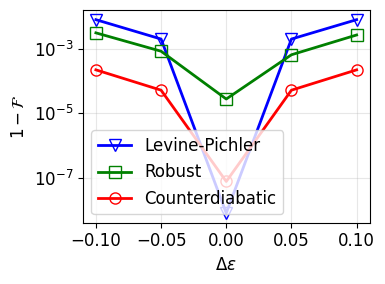

In [82]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Linlist, FLevineLin, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FRobustLin, label='Robust', color='green', marker='s', mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FCounterLin, label='Counterdiabatic', color='red', marker='o', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Delta\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Robustness_lin_plot.svg', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()

**Now we study the effect of lifetimes. First, we define a counterdiabatic gate with decay**

In [53]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt
    
class CZGateCounterDecay:

    def __init__(self,  decay: float):
        self._decay = decay
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex), jnp.array([1,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float ) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            decay=self._decay
            return jnp.array(
                [
                   [0,(Omega-1j*Xi)*0.5],
                   [(Omega+1j*Xi)*0.5,Delta - 1j * 0.5 * decay],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float ) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            decay=self._decay   
            return jnp.array(
                 [
                   [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2)],
                   [(Omega+1j*Xi)*0.5*jnp.sqrt(2),Delta - 1j *0.5* decay]
                                                        
                ]
            )
        return hamiltonian1, hamiltonian2

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

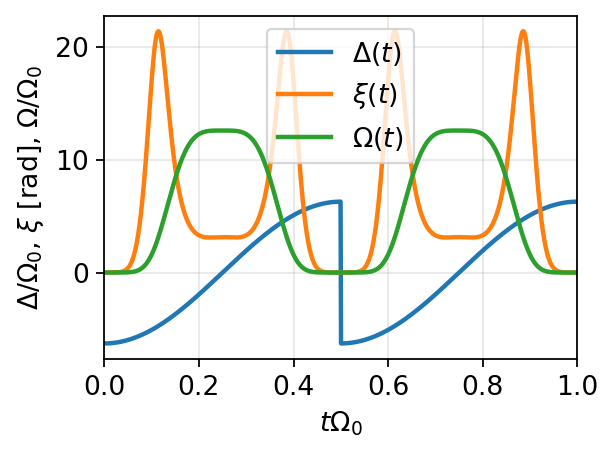

In [54]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
lifetime80=260.3716142904322
lifetime40=52.4944355559069
gate = CZGateCounterDecay(1/lifetime40)
initial_params=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])
fixed_initial_params = (True, [False], [False], [False])
ro.characterization.plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);


In [55]:
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states).item()

0.9928860913022912

**Here we calculate the dependence of fidelities on gate duration taking into account lifetime of Rydberg 80P state**

In [56]:
lifetime80=260.3716142904322

TPulse=[0.1,0.2,0.5,1]
Flife80=[]
for i in range(len(TPulse)):
    Decay=TPulse[i]/lifetime80
    gate = CZGateCounterDecay(Decay)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Flife80.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Flife80

[0.00014408631387863302,
 0.0002880727931244831,
 0.0007198872138816093,
 0.00143909471885717]

**Here we calculate the dependence of fidelities on gate duration taking into account lifetime of Rydberg 50P state**

In [57]:
lifetime50=89.16015139780312
Flife50=[]
for i in range(len(TPulse)):
    Decay=TPulse[i]/lifetime50
    gate = CZGateCounterDecay(Decay)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Flife50.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Flife50

[0.00042055778039995495,
 0.0008408337384712139,
 0.0021004252357447184,
 0.004195629185433258]

**Here we calculate the dependence of fidelities on gate duration taking into account lifetime of Rydberg 110P state**

In [58]:
lifetime110=525.415355114723
Flife110=[]
for i in range(len(TPulse)):
    Decay=TPulse[i]/lifetime110
    gate = CZGateCounterDecay(Decay)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Flife110.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Flife110

[7.144366134337332e-05,
 0.00014280581614067867,
 0.0003568566675242746,
 0.0007134892689431016]

**Plot shows dependence of fidelity on gate duration for three Rydberg lifetimes**

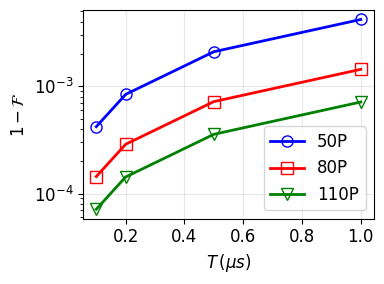

In [59]:
fig, ax = plt.subplots(figsize=(4, 3))

# Plot the first series
ax.plot(TPulse, Flife50, label='50P', color='blue', marker='o',mfc='none', markersize=8)

# Plot the second series
ax.plot(TPulse, Flife80, label='80P', color='red', marker='s', mfc='none', markersize=8)

# Plot the second series
ax.plot(TPulse, Flife110, label='110P', color='green', marker='v', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$T\, (\mu s) $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('SinglePhotonLifetime', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()

**Here we generalize the gate definition to take into account decay and finite blockade strength**

In [60]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt
    
class CZGateCounterDecayV:

    def __init__(self,  decay: float, Vnn: float):
        self._decay = decay
        self._Vnn = Vnn
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex), jnp.array([1,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float ) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            decay=self._decay
            
            return jnp.array(
                [
                   [0,(Omega-1j*Xi)*0.5],
                   [(Omega+1j*Xi)*0.5,Delta - 1j * 0.5 * decay],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float ) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            decay=self._decay 
            Vnn=self._Vnn
            return jnp.array(
                 
                  [
                   [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2),0],
                   [(Omega+1j*Xi)*0.5*jnp.sqrt(2),Delta- 1j *0.5* decay,(Omega+1j*Xi)*0.5*jnp.sqrt(2)],
                    [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2),2*Delta+Vnn-1j *  decay]                                    
                ]
                
            )
        return hamiltonian1, hamiltonian2

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

In [376]:
gate = CZGateCounterDecayV(1/lifetime50,100)

time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, optimized_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.004230758596926232

**Lifetimes for Cs**

In [379]:
lifetime80Cs=293.1136364044113

TPulse=[0.1,0.2,0.5,1]
Flife80Cs=[]
for i in range(len(TPulse)):
    Decay=TPulse[i]/lifetime80Cs
    gate = CZGateCounterDecay(Decay)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Flife80Cs.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Flife80Cs

[0.00012877164012214948,
 0.00025666168635463116,
 0.0006402167788190916,
 0.001279093714847801]

In [384]:
lifetime50Cs=100.44062114264784

TPulse=[0.1,0.2,0.5,1]
Flife50Cs=[]
for i in range(len(TPulse)):
    Decay=TPulse[i]/lifetime50Cs
    gate = CZGateCounterDecay(Decay)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Flife50Cs.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Flife50Cs

[0.0003740831849614601,
 0.0007471412375449349,
 0.0018653406641896408,
 0.003725763340021504]

In [385]:
lifetime110Cs=596.010844103981

TPulse=[0.1,0.2,0.5,1]
Flife110Cs=[]
for i in range(len(TPulse)):
    Decay=TPulse[i]/lifetime110Cs
    gate = CZGateCounterDecay(Decay)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Flife110Cs.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Flife110Cs

[6.376992914347568e-05,
 0.00012667228004659137,
 0.0003153517120346727,
 0.0006297255320214523]

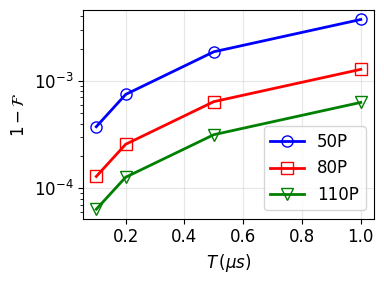

In [386]:
fig, ax = plt.subplots(figsize=(4, 3))

# Plot the first series
ax.plot(TPulse, Flife50Cs, label='50P', color='blue', marker='o',mfc='none', markersize=8)

# Plot the second series
ax.plot(TPulse, Flife80Cs, label='80P', color='red', marker='s', mfc='none', markersize=8)

# Plot the second series
ax.plot(TPulse, Flife110Cs, label='110P', color='green', marker='v', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$T\, (\mu s) $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('SinglePhotonLifetimeCs', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()

In [ ]:
tlist=np.linspace(0,1,100)
plt.plot(tlist,counterdia(tlist,duration=1, ansatz_params=[12.65512053,  9.58871939, 12.65512053,  9.58871939]))